# Breast Ultrasound Classification (BUSI Dataset)

Goal:
Classify ultrasound images into:
- benign
- malignant
- normal


In [ ]:
# install kagglehub
!pip install kagglehub

In [ ]:
import kagglehub
import os

# download dataset
path = kagglehub.dataset_download("subhajournal/busi-breast-ultrasound-images-dataset")

print("Dataset path:", path)

# list folders
os.listdir(path)

100%|██████████| 195M/195M [00:01<00:00, 132MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/subhajournal/busi-breast-ultrasound-images-dataset/versions/1


['Dataset_BUSI_with_GT']

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
data_dir = os.path.join(path, "Dataset_BUSI_with_GT")

print(os.listdir(data_dir))

['malignant', 'normal', 'benign']


In [ ]:
# simple preprocessing

img_size = (128,128)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="training"
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation"
)

Found 1263 images belonging to 3 classes.
Found 315 images belonging to 3 classes.


In [ ]:
model = models.Sequential([

    layers.Conv2D(32, (3,3), activation="relu", input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64,(3,3),activation="relu"),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128,(3,3),activation="relu"),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dense(3, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.5685 - loss: 0.8740 - val_accuracy: 0.5873 - val_loss: 0.7988
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.6912 - loss: 0.6924 - val_accuracy: 0.7016 - val_loss: 0.7261
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.7751 - loss: 0.5171 - val_accuracy: 0.7238 - val_loss: 0.7163
Epoch 4/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.8337 - loss: 0.4084 - val_accuracy: 0.6889 - val_loss: 0.9071
Epoch 5/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.8733 - loss: 0.3136 - val_accuracy: 0.7365 - val_loss: 0.7614


In [ ]:
loss, acc = model.evaluate(val_data)

print("Loss:", loss)
print("Accuracy:", acc)

10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 341ms/step - accuracy: 0.7365 - loss: 0.7614
Loss: 0.7614047527313232
Accuracy: 0.7365079522132874


In [ ]:
val_data.reset()

pred = model.predict(val_data)

y_pred = np.argmax(pred, axis=1)
y_true = val_data.classes

print("Total samples:", len(y_true))

10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 345ms/step
Total samples: 315


In [ ]:
cm = confusion_matrix(y_true, y_pred)

print(cm)

[[125  32  21]
 [ 66  10   8]
 [ 37   9   7]]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step


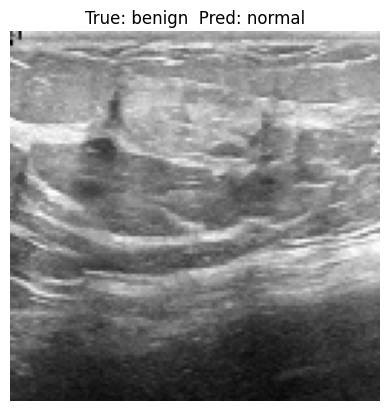

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


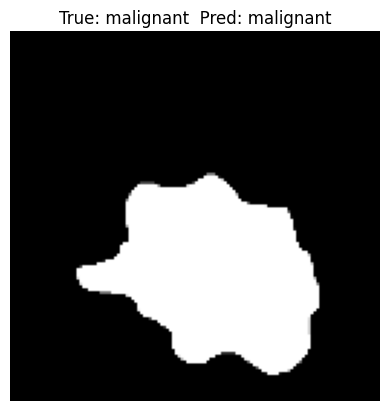

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


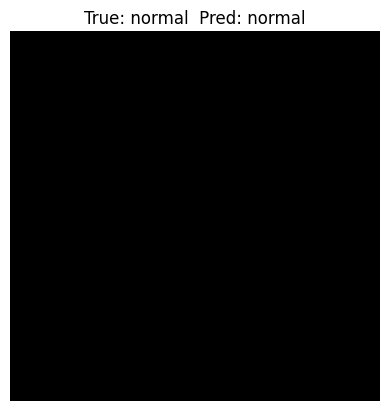

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


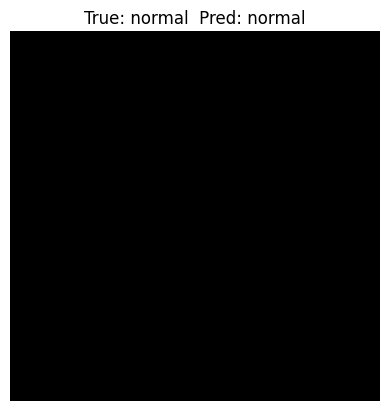

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


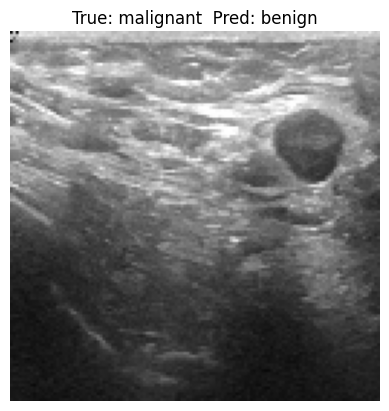

In [44]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import random

classes = ["benign", "malignant", "normal"]

img_size = 128   # code1 used 128

for i in range(5):

    cls = random.choice(classes)

    folder = os.path.join(data_dir, cls)

    file = random.choice(os.listdir(folder))

    img_path = os.path.join(folder, file)

    img = cv2.imread(img_path)
    img = cv2.resize(img, (img_size, img_size))

    img_array = img / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)

    pred_class = classes[np.argmax(pred)]

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"True: {cls}  Pred: {pred_class}")
    plt.axis("off")
    plt.show()

In [ ]:
labels = list(val_data.class_indices.keys())

print(classification_report(
    y_true,
    y_pred,
    target_names=labels
))

              precision    recall  f1-score   support

      benign       0.55      0.70      0.62       178
   malignant       0.20      0.12      0.15        84
      normal       0.19      0.13      0.16        53

    accuracy                           0.45       315
   macro avg       0.31      0.32      0.31       315
weighted avg       0.39      0.45      0.41       315



Before SMOTE: Counter({np.int32(0): 713, np.int32(1): 337, np.int32(2): 213})


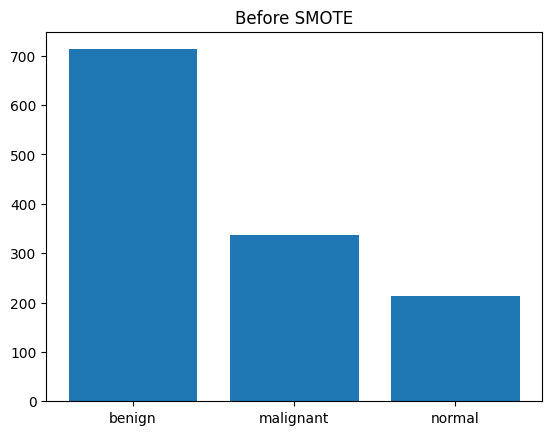

In [41]:
# count before SMOTE

import matplotlib.pyplot as plt
from collections import Counter

counter_before = Counter(y)

print("Before SMOTE:", counter_before)

labels = ["benign", "malignant", "normal"]
values = [counter_before[i] for i in range(3)]

plt.bar(labels, values)
plt.title("Before SMOTE")
plt.show()

Conclusion

Overall accuracy is around 73%, but the classification report shows
that the model predicts benign class much better than malignant and normal.

This happens because the dataset is imbalanced and contains more benign images.

Model thinks: Most images are benign and  predict benign often

# After SMOTE

In [1]:
import kagglehub
import os

path = kagglehub.dataset_download(
    "subhajournal/busi-breast-ultrasound-images-dataset"
)

data_dir = os.path.join(path, "Dataset_BUSI_with_GT")

print(os.listdir(data_dir))

100%|██████████| 195M/195M [00:07<00:00, 26.8MB/s]

Extracting files...


['benign', 'normal', 'malignant']


In [2]:
import numpy as np
import cv2
import os

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.metrics import classification_report, confusion_matrix

In [3]:
img_size = 64

classes = ["benign", "malignant", "normal"]

X = []
y = []

for label, cls in enumerate(classes):

    folder = os.path.join(data_dir, cls)

    for file in os.listdir(folder):

        if file.endswith(".png"):

            img_path = os.path.join(folder, file)

            img = cv2.imread(img_path)

            img = cv2.resize(img, (img_size, img_size))

            X.append(img)
            y.append(label)


X = np.array(X)
y = np.array(y)

print("Images:", X.shape)
print("Labels:", y.shape)

Images: (1578, 64, 64, 3)
Labels: (1578,)


In [4]:
X_flat = X.reshape(len(X), -1)

print(X_flat.shape)

(1578, 12288)


In [5]:
smote = SMOTE()

X_res, y_res = smote.fit_resample(X_flat, y)

print("After SMOTE:", X_res.shape)

After SMOTE: (2673, 12288)


In [6]:
X_res = X_res.reshape(-1, img_size, img_size, 3)

print(X_res.shape)

(2673, 64, 64, 3)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res,
    y_res,
    test_size=0.2,
    random_state=42
)

y_train = tf.keras.utils.to_categorical(y_train, 3)
y_test = tf.keras.utils.to_categorical(y_test, 3)

In [8]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [9]:
model = models.Sequential([

    layers.Conv2D(32,(3,3),activation="relu",
                  input_shape=(img_size,img_size,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64,(3,3),activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128,activation="relu"),
    layers.Dense(3,activation="softmax")

])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,587 (2.61 MB)

 Trainable params: 683,587 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 16s 200ms/step - accuracy: 0.5706 - loss: 0.8598 - val_accuracy: 0.6542 - val_loss: 0.7003
Epoch 2/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 17s 149ms/step - accuracy: 0.6857 - loss: 0.6404 - val_accuracy: 0.6972 - val_loss: 0.6245
Epoch 3/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 12s 171ms/step - accuracy: 0.7353 - loss: 0.5735 - val_accuracy: 0.7327 - val_loss: 0.5913
Epoch 4/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 20s 161ms/step - accuracy: 0.7666 - loss: 0.5112 - val_accuracy: 0.7907 - val_loss: 0.4872
Epoch 5/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 10s 152ms/step - accuracy: 0.8087 - loss: 0.4300 - val_accuracy: 0.8187 - val_loss: 0.4441
Epoch 6/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 11s 158ms/step - accuracy: 0.8527 - loss: 0.3512 - val_accuracy: 0.8355 - val_loss: 0.4102
Epoch 7/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 10s 153ms/step - accuracy: 0.8971 - loss: 0.2608 - val_accuracy: 0.8374 - val_loss: 0.4479
Epoch 8/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 10s 149ms/step - accuracy: 0.9125 - loss: 0.2245 - val_accu

In [11]:
loss, acc = model.evaluate(X_test, y_test)

print("Loss:", loss)
print("Accuracy:", acc)

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8766 - loss: 0.4134
Loss: 0.41344359517097473
Accuracy: 0.8766354918479919


In [12]:
pred = model.predict(X_test)

y_pred = np.argmax(pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print("Samples:", len(y_true))

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
Samples: 535


In [13]:
cm = confusion_matrix(y_true, y_pred)

print(cm)

[[148  24   3]
 [  9 169   5]
 [ 10  15 152]]


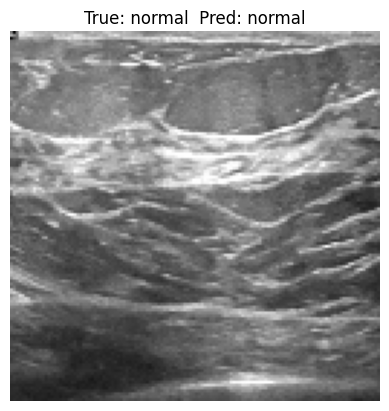

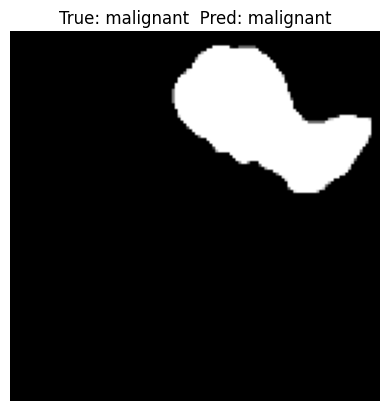

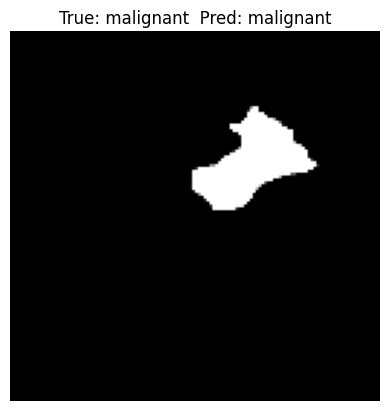

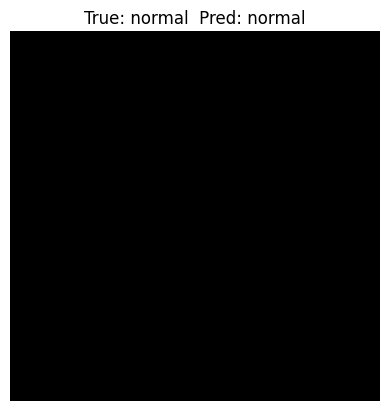

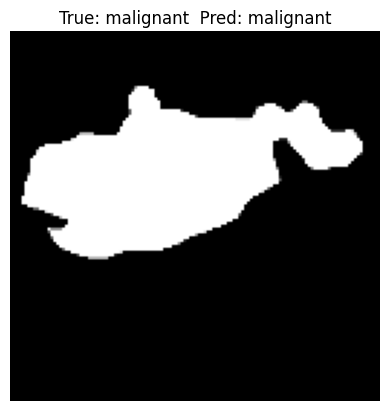

In [48]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import random

classes = ["benign", "malignant", "normal"]


img_size = model.input_shape[1]

for i in range(5):

    cls = random.choice(classes)

    folder = os.path.join(data_dir, cls)

    file = random.choice(os.listdir(folder))

    img_path = os.path.join(folder, file)

    img = cv2.imread(img_path)
    img = cv2.resize(img, (img_size, img_size))

    img_array = img / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array, verbose=0)

    pred_class = classes[np.argmax(pred)]

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"True: {cls}  Pred: {pred_class}")
    plt.axis("off")
    plt.show()

In [14]:
labels = ["benign", "malignant", "normal"]

print(classification_report(
    y_true,
    y_pred,
    target_names=labels
))

              precision    recall  f1-score   support

      benign       0.89      0.85      0.87       175
   malignant       0.81      0.92      0.86       183
      normal       0.95      0.86      0.90       177

    accuracy                           0.88       535
   macro avg       0.88      0.88      0.88       535
weighted avg       0.88      0.88      0.88       535



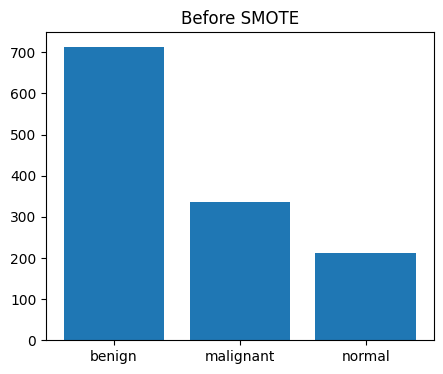

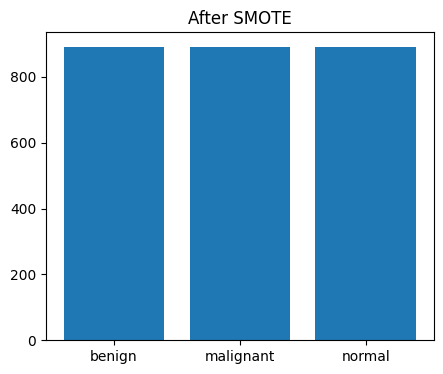

In [43]:
def plot_counts(y, title):

    from collections import Counter

    c = Counter(y)

    labels = ["benign", "malignant", "normal"]
    values = [c[i] for i in range(3)]

    plt.figure(figsize=(5,4))
    plt.bar(labels, values)
    plt.title(title)
    plt.show()


plot_counts(y, "Before SMOTE")

plot_counts(y_sm, "After SMOTE")

Bar graph shows dataset imbalance before SMOTE.
After applying SMOTE, all classes become balanced.
This helps model learn minority classes better.

Before:

malignant → predicted benign

normal → predicted benign

After SMOTE:

malignant → predicted malignant

normal → predicted normal

Because model saw more samples.

# **Conclusion:**

Model thinks: All classes equally important

*Before* applying SMOTE, the BUSI dataset was imbalanced,
with more benign images than malignant and normal images.

Because of this imbalance, the CNN model learned to predict
the benign class more often, resulting in low accuracy for
malignant and normal classes.

After applying SMOTE, synthetic samples were created for
minority classes, making the dataset balanced.

Due to balanced training data, the model learned all classes
equally, which improved the classification performance.

Accuracy increased from about 73% to 87%, and the F1-score
for malignant and normal classes improved significantly.

This shows that SMOTE is effective for handling class
imbalance in medical image classification.